# 08 -- Malaysia Deep Dive

## Research Question
What does everything in this project mean specifically for Malaysia -- its dependencies, its vulnerabilities, and its real opportunities?

## Data
DOSM (trade headline, SITC, BEC), UN Comtrade (Malaysia bilateral), World Bank LPI (ASEAN-6), USGS (Malaysia's mineral position). Full framework in `docs/MALAYSIA_FRAMEWORK.md`.

## Method
Supplier/customer concentration (HHI) from bilateral data; 5-dimension Vulnerability Index; 4-hypothesis Opportunity Radar, each explicitly evidence-graded rather than presented with uniform confidence.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
import sys, os
sys.path.insert(0, os.path.abspath('../python/visualisation'))
pd.set_option('display.max_columns', 20)

In [2]:
suppliers = pd.read_csv('../data/processed/malaysia_top_suppliers_2023.csv')
customers = pd.read_csv('../data/processed/malaysia_top_customers_2023.csv')
print("Malaysia's top 5 suppliers, 2023:")
print(suppliers.head(5)[['supplier','share_pct']].round(1).to_string(index=False))
print("\nMalaysia's top 5 customers, 2023:")
print(customers.head(5)[['customer','share_pct']].round(1).to_string(index=False))

Malaysia's top 5 suppliers, 2023:
     supplier  share_pct
        China       34.1
    Singapore       17.4
United States        7.6
        Japan        5.4
    Indonesia        5.0

Malaysia's top 5 customers, 2023:
            customer  share_pct
           Singapore       15.8
       United States       15.6
               China       13.9
Hong Kong SAR, China        6.5
               Japan        6.2


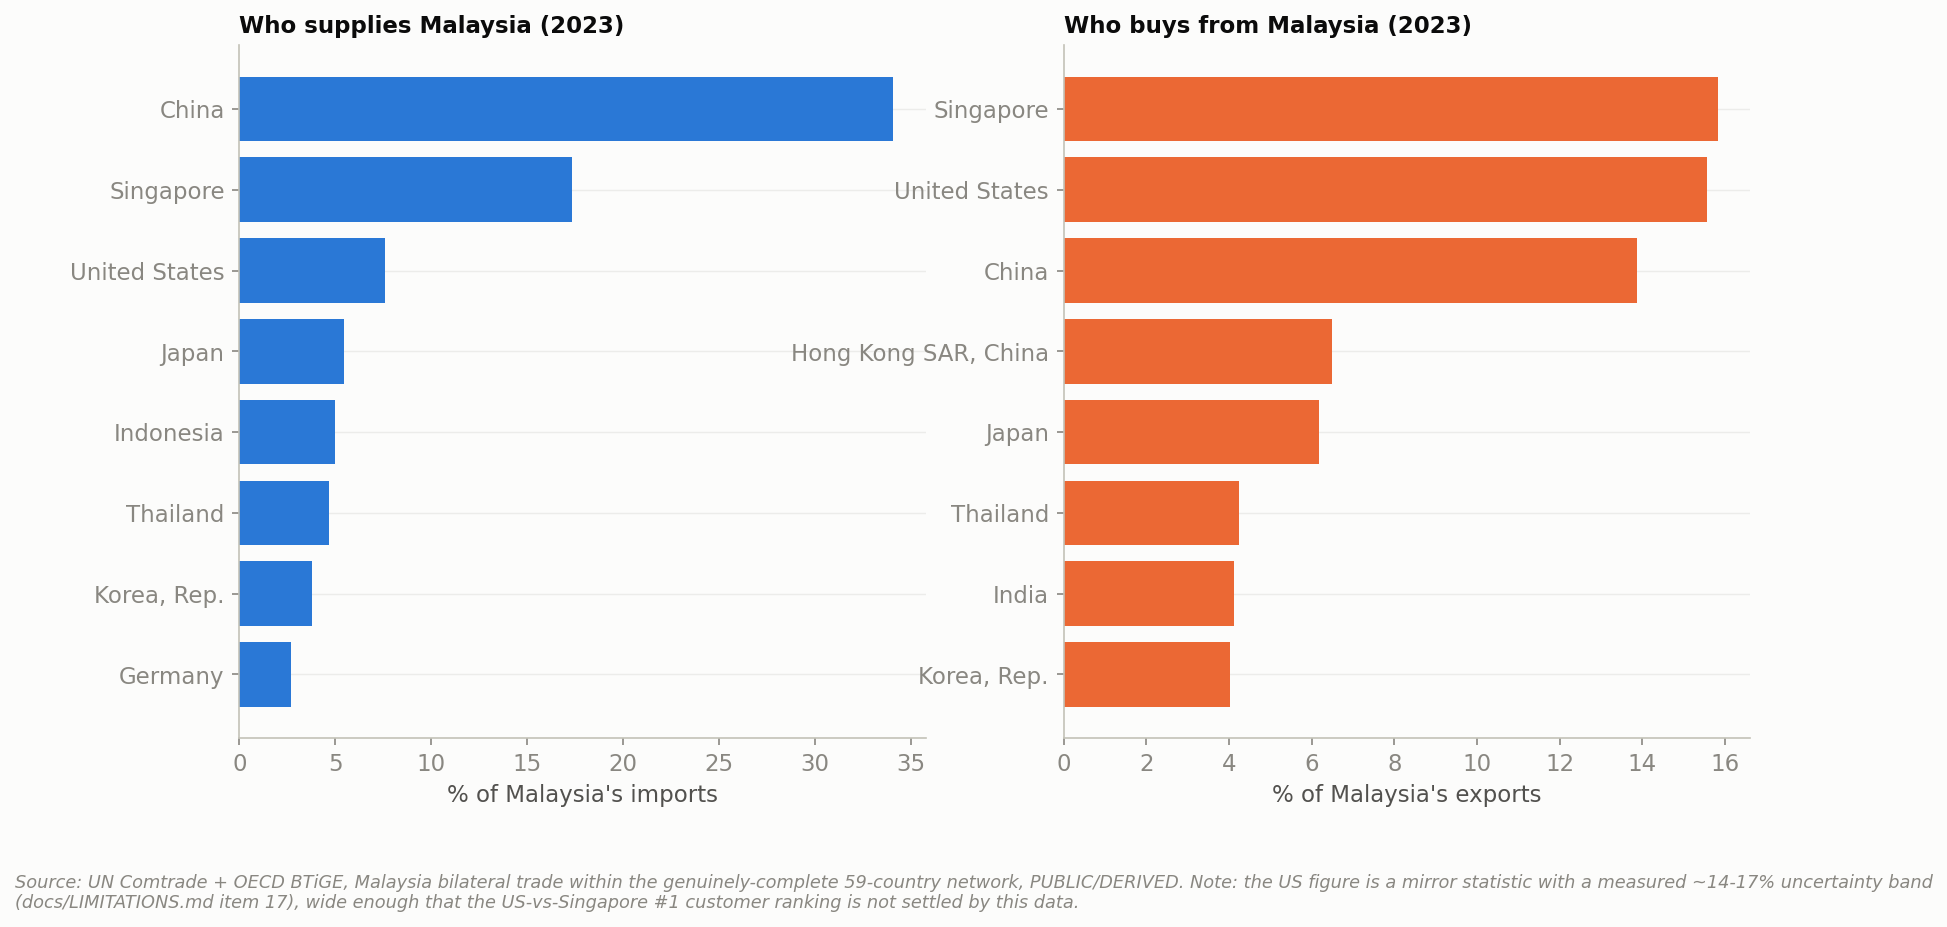

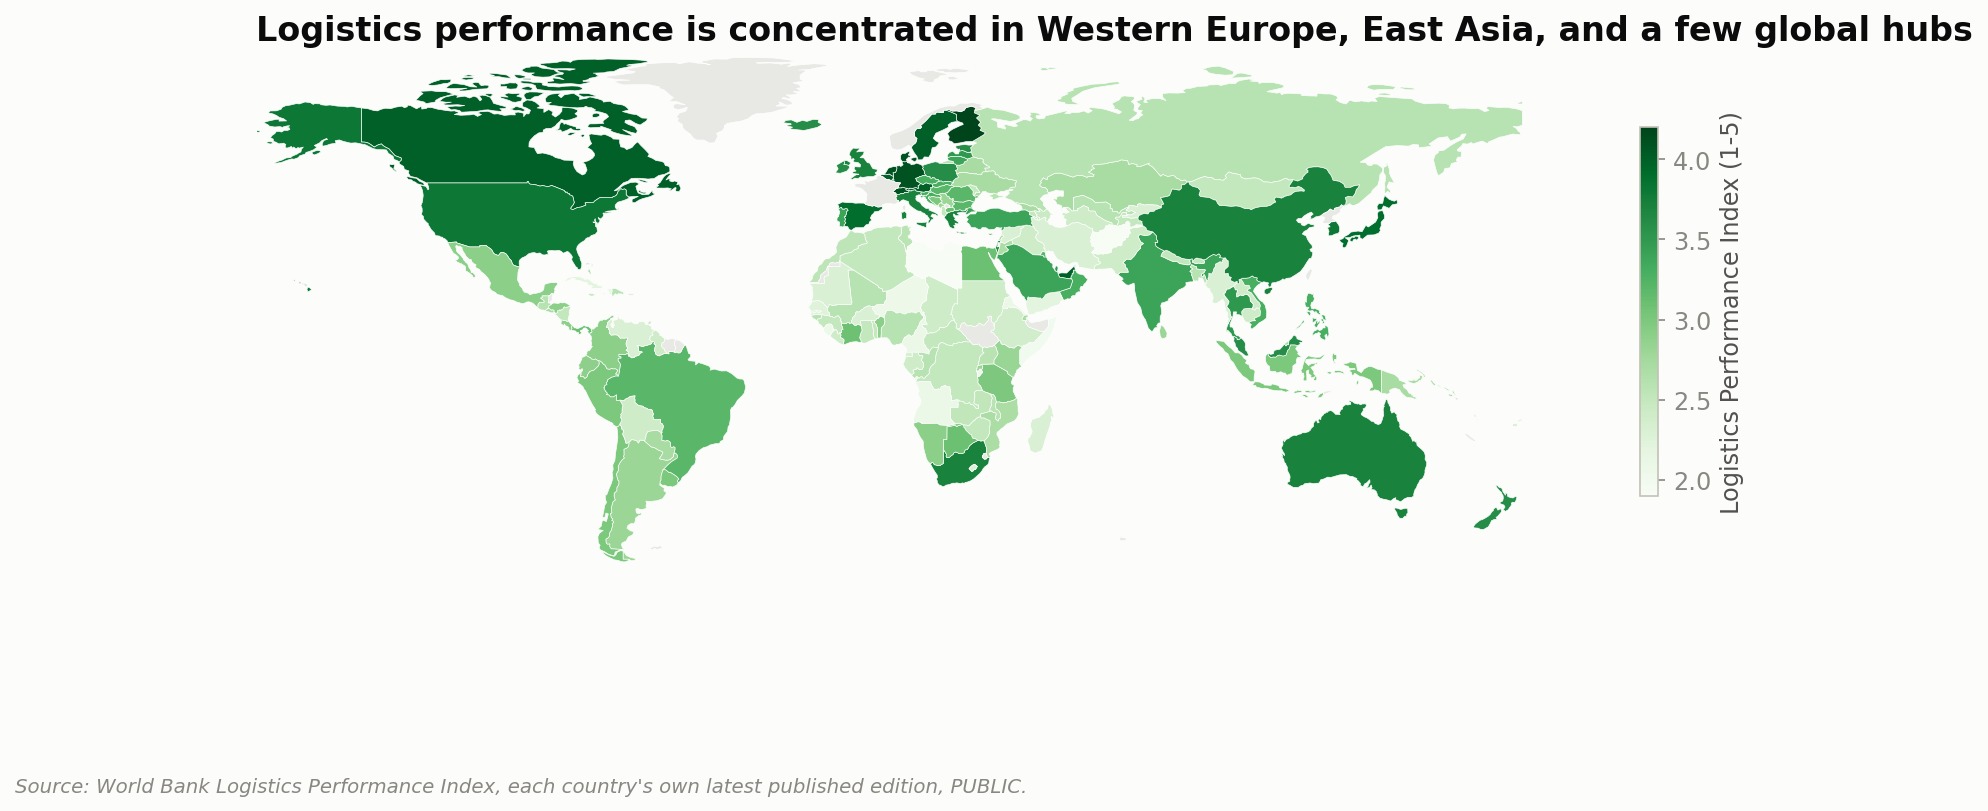

In [3]:
display(Image('../outputs/figures/15_malaysia_suppliers_customers.png', width=750))
display(Image('../outputs/figures/08_logistics_performance_map.png', width=950))

                                                     dimension  raw_value  score_0_100
               Import dependency (% GDP, vs. 59-country peers)       33.2         33.2
          Supplier concentration (HHI, Malaysia's own imports)     1645.8         16.5
          Customer concentration (HHI, Malaysia's own exports)      880.3          8.8
      Logistics fragility (inverted LPI, vs. 59-country peers)       31.8         31.8
Production-input import share (DOSM BEC, capital+intermediate)       85.9         85.9


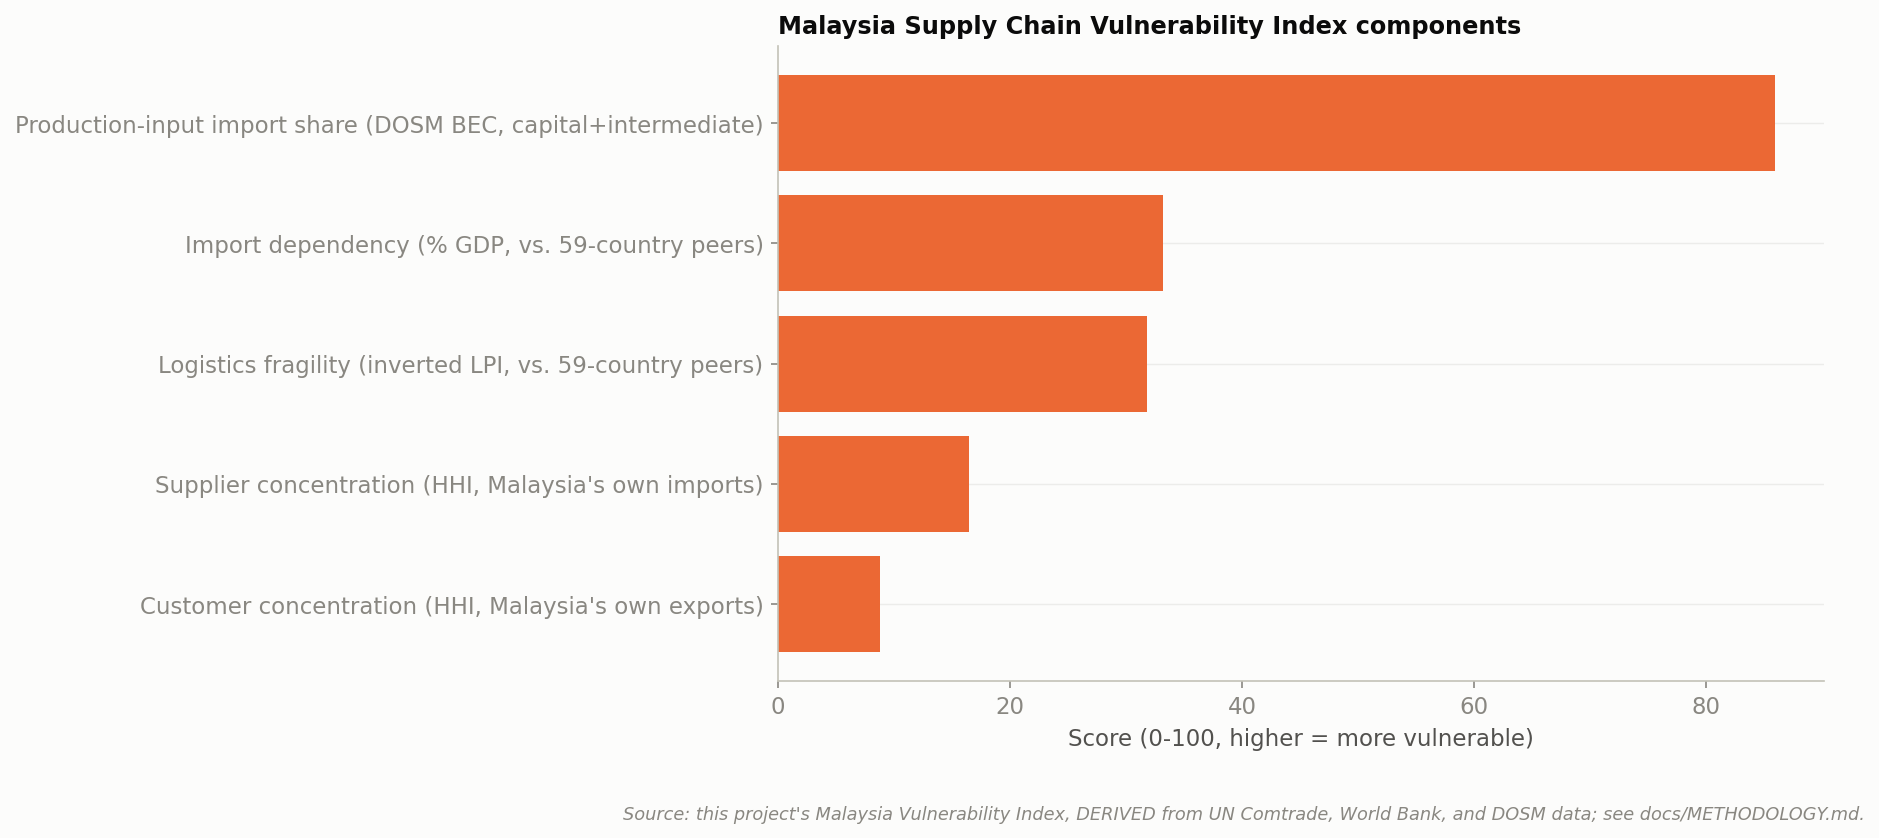

In [4]:
vuln = pd.read_csv('../data/processed/malaysia_vulnerability_index.csv')
print(vuln.round(1).to_string(index=False))
display(Image('../outputs/figures/16_malaysia_vulnerability_dashboard.png', width=650))

                                           opportunity                                                                 evidence_strength
Electronics & semiconductors (assembly/test/packaging)                                                   Strong (direct DOSM trade data)
                 Regional logistics / distribution hub                                        Strong (World Bank LPI, direct comparison)
   Critical-minerals processing / downstream value-add Weak / speculative -- named as a hypothesis, not confirmed by this project's data
                 Data centres / digital infrastructure                    Not evidenced by this project -- flagged as a gap, not claimed


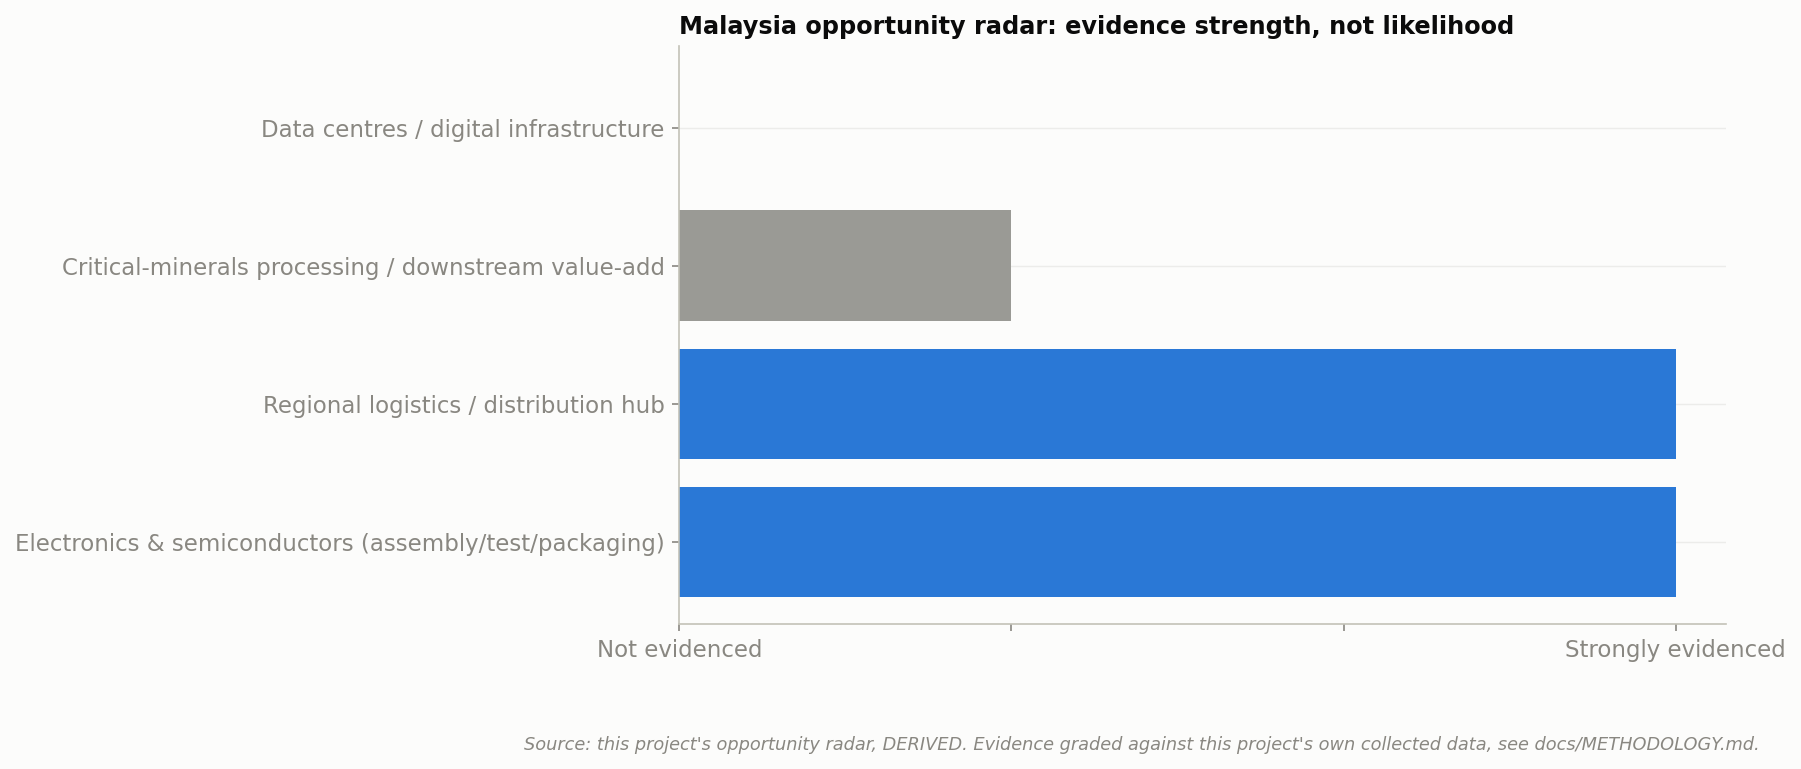

In [5]:
opp = pd.read_csv('../data/processed/malaysia_opportunity_radar.csv')
print(opp[['opportunity','evidence_strength']].to_string(index=False))
display(Image('../outputs/figures/17_malaysia_opportunity_radar.png', width=650))

## Strategic Findings

### Finding 1: China dominates Malaysia's supplier side; the customer side genuinely cannot be ranked precisely with this project's data

**DATA:** China is Malaysia's largest supplier by a wide margin (34.1% of imports, 2023), a directly-reported figure. On the customer side, Singapore (15.8%) and China (13.9%) are directly reported; the US figure (15.6%) is a mirror statistic (the US's own import report, since Malaysia's own export report to the US is absent from UN Comtrade's free tier), and this project measured that kind of edge's typical discrepancy at this trade relationship's size (~14-17% for flows this large, `docs/LIMITATIONS.md` item 17), implying a true value plausibly anywhere from $39-55 billion, wide enough to span both Singapore's and China's directly-reported figures. Malaysia's supplier concentration rose sharply between 2016 and 2023 (HHI 1,235 to 1,646); customer concentration held roughly flat (HHI 914 to 880).

**INSIGHT:** The "China+1 diversification" narrative does not show up on Malaysia's supplier side (concentration is genuinely rising); it is not strongly contradicted on the customer side either, since that concentration is roughly flat, not falling. Separately, the US is genuinely competitive with Singapore for Malaysia's #1 customer position, an important strategic fact even though this project's data cannot say which one is actually larger; reporting a precise ranking anyway would trade honesty for false precision.

**BUSINESS IMPLICATION:** A business assuming Malaysia's trade base has been actively diversifying away from China, based on regional headlines rather than Malaysia's own bilateral figures, would be planning against a trend that this project's data does not support.

**STRATEGIC CONSIDERATION:** Supply-chain risk assessments specific to Malaysia should treat rising concentration as the current baseline and monitor it directly with bilateral trade data, rather than inferring Malaysia's position from broader ASEAN or "China+1" narratives that may not hold at the country level.

### Finding 2: Malaysia's opportunity case is strongest in electronics, weakest in minerals processing

**DATA:** Electronics/semiconductor assembly-test-packaging is Malaysia's largest real export category (50.3% of exports by SITC section, roughly RM808 billion in 2025), anchored by named, publicly reported investments (Infineon's RM30 billion Kulim silicon-carbide fab, Micron's Muar/Prai/Batu Kawan facilities, ASE Technology's fifth Penang plant, February 2025, added after external review, see docs/SOURCES.md. A real volatility signal from the same period: Intel paused its own Penang project in early 2025 during a financial restructuring, but as of the most recent reporting checked the facility is 99% complete and set to commence operations later in 2026, a reversal, not a permanent exit). Malaysia holds the 2nd-highest logistics performance score in ASEAN-6, behind only Singapore, directly grounded in the Strait of Malacca (23.2 million barrels/day, 29% of global maritime oil flows, the world's largest oil-transit chokepoint, running along Malaysia's own coastline) and real container-port-traffic growth (20.9 to 30.7 million TEU, 2013-2024). Malaysia's own critical-minerals production share is under 2.3% for every one of the 13 tracked materials.

**INSIGHT:** The evidence for Malaysia's near-term opportunities is uneven by design, not by omission: electronics and regional logistics are strongly evidenced by real export and LPI data, while a critical-minerals-processing opportunity would depend on imported feedstock, not a domestic resource advantage, and is graded accordingly as weak/speculative rather than presented with the same confidence.

**BUSINESS IMPLICATION:** An investment or partnership thesis built on "Malaysia as a critical-minerals hub" is not supported by this project's production data; a thesis built on Malaysia's electronics assembly-test-packaging strength and regional logistics position is, on the same evidence standard.

**STRATEGIC CONSIDERATION:** Businesses and policymakers evaluating Malaysia's industrial-policy opportunities should weight electronics and logistics positioning ahead of a minerals-processing narrative, unless new evidence (feedstock-import agreements, processing capacity data) specifically closes that gap; this project names the gap rather than filling it with assumption.

### Finding 3: Malaysia's import base is production-oriented, not consumption-oriented

**DATA:** 86% of Malaysia's retained imports are production inputs (capital and intermediate goods), not final consumption goods, based on DOSM's 2025 BEC end-use classification (an earlier version double-counted each category's total alongside its own sub-breakdown before the bec-code convention was verified directly against the data, see `docs/DATA_QUALITY.md` item 6).

**INSIGHT:** Malaysia's import profile is direct evidence of deep embedding in upstream manufacturing supply chains, not primarily an import-for-domestic-consumption economy; this reframes what an "import shock" would actually disrupt.

**BUSINESS IMPLICATION:** A tariff, logistics disruption, or supplier-concentration shock hitting Malaysia's imports would most directly hit its manufacturing output and export capacity, not household consumption, a materially different transmission path than in a consumption-import-heavy economy.

**STRATEGIC CONSIDERATION:** Scenario planning for Malaysia-specific supply shocks (see `docs/SCENARIO_METHODOLOGY.md`) should trace impact through the production-input channel first; that is where 86% of the actual import exposure sits.

## Limitation

No Malaysia state/cluster-level analysis was built, no sufficiently granular free dataset was found, and forcing a weak proxy would have violated this project's own evidence standard. See `docs/LIMITATIONS.md` item 5.

## Next Step

This is the final notebook in the series. See the README's "Key Strategic Insights" and "Malaysia 2030+ Opportunities & Risks" sections for the synthesis across all eight notebooks.
